In [1]:

import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values


In [4]:
# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

In [5]:
# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y

In [6]:
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot


In [7]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


In [8]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)


In [9]:
X_train.shape,X_val.shape,y_train_one_hot.shape,y_val_one_hot.shape,y_train.shape,y_val.shape

((5881, 128, 9), (1471, 128, 9), (5881, 6), (1471, 6), (5881, 1), (1471, 1))

In [10]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, Concatenate, Multiply, Reshape,
    BatchNormalization, Activation, Add
)
from tensorflow.keras.optimizers import Adam

In [12]:
def squeeze_excitation_block(input_tensor, channels, reduction=16):
    """Squeeze-and-Excitation Block"""
    # Squeeze: Global Average Pooling
    se = GlobalAveragePooling1D()(input_tensor)

    # Excitation: FC layers
    se = Dense(channels // reduction, activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)

    # Reshape to match input dimensions
    se = Reshape((1, channels))(se)

    # Scale
    output = Multiply()([input_tensor, se])

    return output


In [13]:
def inception_module(input_tensor, filters):
    """Inception Module for 1D time series"""

    # Branch 1: 1x1 convolution
    branch1 = Conv1D(filters // 4, kernel_size=1, padding='same')(input_tensor)
    branch1 = BatchNormalization()(branch1)
    branch1 = Activation('relu')(branch1)

    # Branch 2: 1x1 -> 3x3 convolution
    branch2 = Conv1D(filters // 4, kernel_size=1, padding='same')(input_tensor)
    branch2 = BatchNormalization()(branch2)
    branch2 = Activation('relu')(branch2)
    branch2 = Conv1D(filters // 4, kernel_size=3, padding='same')(branch2)
    branch2 = BatchNormalization()(branch2)
    branch2 = Activation('relu')(branch2)

    # Branch 3: 1x1 -> 5x5 convolution
    branch3 = Conv1D(filters // 4, kernel_size=1, padding='same')(input_tensor)
    branch3 = BatchNormalization()(branch3)
    branch3 = Activation('relu')(branch3)
    branch3 = Conv1D(filters // 4, kernel_size=5, padding='same')(branch3)
    branch3 = BatchNormalization()(branch3)
    branch3 = Activation('relu')(branch3)

    # Branch 4: MaxPool -> 1x1 convolution
    branch4 = MaxPooling1D(pool_size=3, strides=1, padding='same')(input_tensor)
    branch4 = Conv1D(filters // 4, kernel_size=1, padding='same')(branch4)
    branch4 = BatchNormalization()(branch4)
    branch4 = Activation('relu')(branch4)

    # Concatenate all branches
    output = Concatenate(axis=-1)([branch1, branch2, branch3, branch4])

    # Apply SE block
    output = squeeze_excitation_block(output, filters)

    return output

In [14]:
def create_se_inception_model(n_timesteps=128, n_features=9, n_outputs=6):
    """
    SE-Inception 모델 생성

    Args:
        n_timesteps: 시퀀스 길이 (기본: 128)
        n_features: 입력 특징 수 (기본: 9)
        n_outputs: 출력 클래스 수 (기본: 6)

    Returns:
        Keras Model
    """

    # Input layer
    inputs = Input(shape=(n_timesteps, n_features))

    # Initial convolution
    x = Conv1D(64, kernel_size=7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    # Inception modules with SE
    x = inception_module(x, 128)
    x = inception_module(x, 256)
    x = inception_module(x, 512)

    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)

    # Fully connected layers
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)

    # Output layer
    outputs = Dense(n_outputs, activation='softmax')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='SE_Inception_HAR')

    return model

In [15]:
model = create_se_inception_model(n_timesteps=128, n_features=9, n_outputs=6)


In [16]:
 # 모델 컴파일
model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
model.summary()

Model: "SE_Inception_HAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 64)    │      4,096 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 32, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 32, 32)    │      2,080 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 32, 32)    │      2,080 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 32, 64)    │          0 │ max_pooling1d[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 32)    │      2,080 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 32)    │      3,104 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 32, 32)    │      5,152 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 32, 32)    │      2,080 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32)    │        128 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 531,966 (2.03 MB)

 Trainable params: 529,150 (2.02 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [17]:
history = model.fit(X_train, y_train_one_hot,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_val, y_val_one_hot),
                    verbose=1)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 47s 111ms/step - accuracy: 0.8040 - loss: 0.5345 - val_accuracy: 0.3923 - val_loss: 2.3291
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9421 - loss: 0.1555 - val_accuracy: 0.9273 - val_loss: 0.1480
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9348 - loss: 0.1741 - val_accuracy: 0.9381 - val_loss: 0.1723
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9391 - loss: 0.1456 - val_accuracy: 0.9545 - val_loss: 0.1216
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9506 - loss: 0.1253 - val_accuracy: 0.9449 - val_loss: 0.1417
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9461 - loss: 0.1278 - val_accuracy: 0.9449 - val_loss: 0.1302
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9413 - loss: 0.1426 - val_accuracy: 0.9375 - val_loss: 0.1438
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9464 - loss: 0.1209 - val_accuracy

In [18]:
test_loss, test_accuracy = model.evaluate(testX, testy_one_hot, verbose=0)

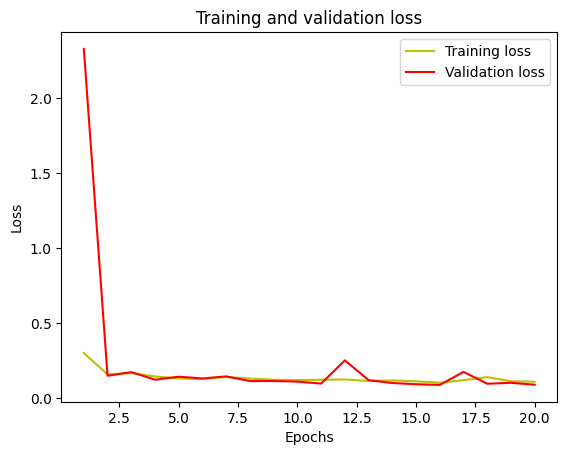

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =history.history['loss']
val_loss =history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

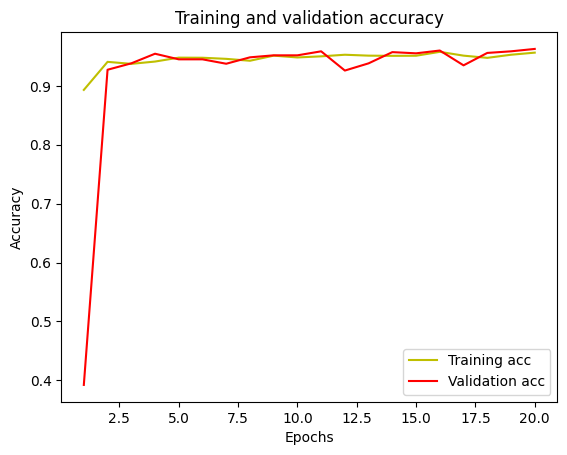

In [20]:


acc =history.history['accuracy']
val_acc =history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [21]:

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
pred=model.predict(testX)
pred=np.argmax(pred, axis=-1)
cm=confusion_matrix(testy,pred)
print(cm)
print(accuracy_score(testy,pred))
print(classification_report(testy,pred))


93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
[[476   0  13   7   0   0]
 [  0 452  12   7   0   0]
 [  0   0 420   0   0   0]
 [  0   1   0 418  66   6]
 [  0   0   0  70 462   0]
 [  0   0   0   0   0 537]]
0.9382422802850356
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       496
           1       1.00      0.96      0.98       471
           2       0.94      1.00      0.97       420
           3       0.83      0.85      0.84       491
           4       0.88      0.87      0.87       532
           5       0.99      1.00      0.99       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



<Axes: >

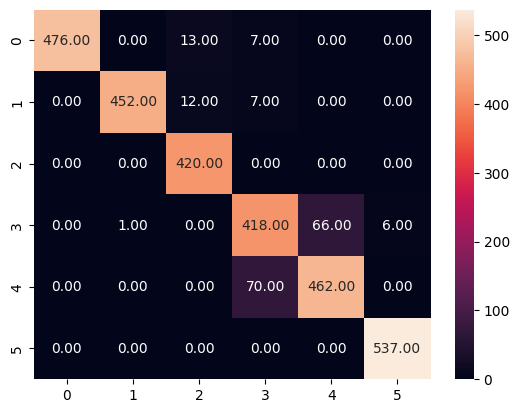

In [22]:
sns.heatmap(cm, annot=True, fmt = '.2f')